##                                                      RAG Evaluation

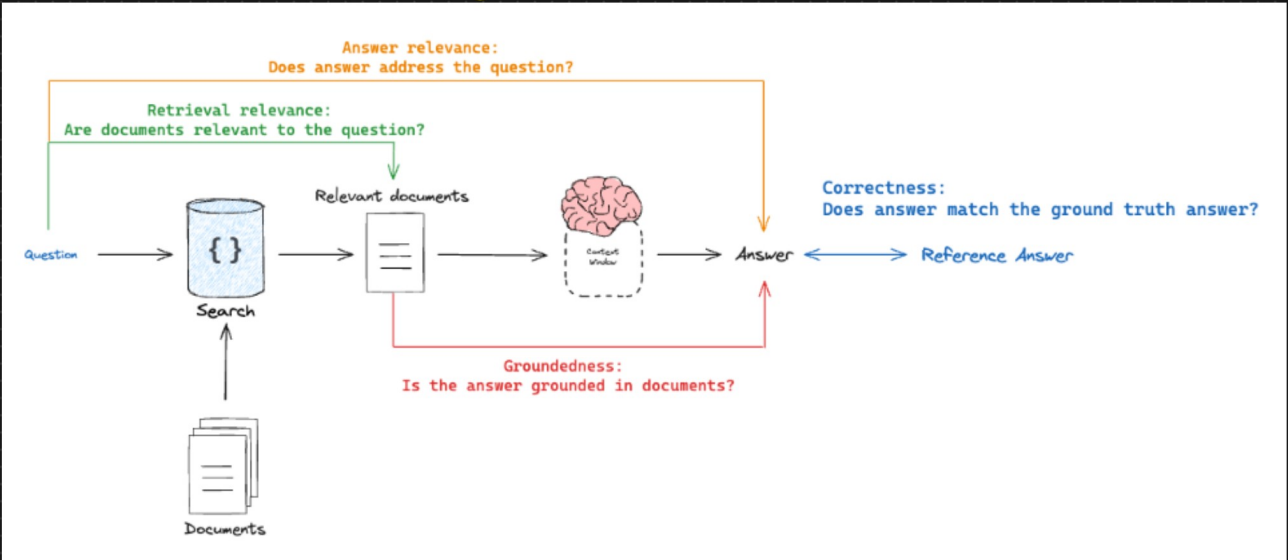

In [1]:
import os
import bs4
from dotenv import load_dotenv
from langsmith import Client
from langchain_groq import ChatGroq
from langsmith import traceable 
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings


load_dotenv()

os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = os.getenv("LANGSMITH_TRACING_V2")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

c:\Users\viren\generative-ai-implementations\langchain\langchain-updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\viren\AppData\Local\Temp\ipykernel_7484\2701715190.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
llm_model = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5423.01it/s]


### RAG Pipeline

In [4]:
# List of URLs to load documents from
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

loader = WebBaseLoader(
    web_paths=urls,
    header_template={"User-Agent": "MyRAGApp/1.0"}, 
    bs_kwargs={
        "parse_only": bs4.SoupStrainer(
        ["article", "main", "div"], 
        class_=["content", "post-text", "body", "post-content"] 
        )
    },
    bs_get_text_kwargs={
        "separator": " ", 
        "strip": True
    }
)
    
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,   
    chunk_overlap=100, 
    separators=["\n\n", "\n", " ", ""]
)

splitted_docs = text_splitter.split_documents(docs)

# Add the document chunks to the "vector store" using OpenAIEmbeddings
vectorstore = InMemoryVectorStore.from_documents(
    documents=splitted_docs,
    embedding=embedding_model,
)

# With langchain we can easily turn any vector store into a retrieval component:
retriever = vectorstore.as_retriever(k=6)

In [5]:
retriever.invoke("what is agents")

[Document(id='10faa1bc-38e9-4be1-bd9c-919d537b5aec', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content="in order to optimize believability at the moment vs in time. Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1) Relationships between agents and observations of one agent by another are all taken into consideration for planning and reacting. Environment information is present in a tree structure. The generative agent architecture. (Image source: Park et al. 2023 ) This fun simulation results in emergent social behavior, such as information diffusion, relationship memory (e.g. two agents continuing the conversation topic) and coordination of social events (e.g. host a party and invite many others). Proof-of-Concept Examples # AutoGPT has drawn a lot of attention into the possibility of setting up autonomous agents with LLM as the main controller. It has quite a lot of reliability issues given the natural language

In [ ]:
## Add decorator
@traceable()
def rag_bot(question:str)->dict:
    ## Relevant context
    docs=retriever.invoke(question)
    docs_string = " ".join(doc.page_content for doc in docs)

    instructions = f"""You are a helpful assistant who is good at analyzing source information and answering questions. 
    Use the following source documents to answer the user's questions.
    If you don't know the answer, just say that you don't know.       
    Use three sentences maximum and keep the answer concise.
    Documents:
    {docs_string}"""
    
    ## llm invoke
    ai_msg = llm_model.invoke([
         {"role": "system", "content": instructions},
        {"role": "user", "content": question},

    ])
    return {"answer": ai_msg.content, "documents": docs}

In [7]:
rag_bot("What is agents")

{'answer': 'Agents are autonomous entities whose behavior is driven by a large language model (LLM) that serves as their “brain.” They combine the LLM with components such as memory, planning, and reflection to perceive observations, maintain relationships, and take actions in an environment. This architecture enables emergent social behaviors like information diffusion, coordination, and sustained conversations.',
 'documents': [Document(id='10faa1bc-38e9-4be1-bd9c-919d537b5aec', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content="in order to optimize believability at the moment vs in time. Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1) Relationships between agents and observations of one agent by another are all taken into consideration for planning and reacting. Environment information is present in a tree structure. The generative agent architecture. (Image source: Park et al. 2023 ) This fun simulation res

### Test RAG 

#### Dataset

In [8]:
client = Client()

# Define the examples for the dataset
examples = [
    {
        "inputs": {"question": "How does the ReAct agent use self-reflection? "},
        "outputs": {"answer": "ReAct integrates reasoning and acting, performing actions - such tools like Wikipedia search API - and then observing / reasoning about the tool outputs."},
    },
    {
        "inputs": {"question": "What are the types of biases that can arise with few-shot prompting?"},
        "outputs": {"answer": "The biases that can arise with few-shot prompting include (1) Majority label bias, (2) Recency bias, and (3) Common token bias."},
    },
    {
        "inputs": {"question": "What are five types of adversarial attacks?"},
        "outputs": {"answer": "Five types of adversarial attacks are (1) Token manipulation, (2) Gradient based attack, (3) Jailbreak prompting, (4) Human red-teaming, (5) Model red-teaming."},
    }
]

### create the daatset and example in LAngsmith
dataset_name="RAG Test Evaluation"
dataset = client.create_dataset(dataset_name=dataset_name)
client.create_examples(dataset_id=dataset.id, examples=examples)

{'example_ids': ['61c58cb3-893c-48dd-97e2-6ca07c2c653a',
  '526bb6ea-5048-4d7f-be6b-672d3d02f52a',
  '90660707-064b-4d57-af61-81a52fb2b2f5'],
 'count': 3,
 'as_of': '2026-07-27T12:17:23.254270907Z'}

### Evaluators or Metrics
1. Correctness: Response vs reference answer
- Goal: Measure "how similar/correct is the RAG chain answer, relative to a ground-truth answer"
- Mode: Requires a ground truth (reference) answer supplied through a dataset
- Evaluator: Use LLM-as-judge to assess answer correctness.

In [ ]:
from typing_extensions import Annotated, TypedDict

## Correctness Output Schema

# Grade output schema
class CorrectnessGrade(TypedDict):
    # Note that the order in the fields are defined is the order in which the model will generate them.
    # It is useful to put explanations before responses because it forces the model to think through
    # its final response before generating it:
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise."]

## correctness prompt

correctness_instructions = """You are a teacher grading a quiz. 

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer. 
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""


grader_llm = llm_model.with_structured_output(CorrectnessGrade, method="json_schema",strict=True)

## evaluator
def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """An evaluator for RAG answer accuracy"""
    answers = f"""\
QUESTION: {inputs['question']}
GROUND TRUTH ANSWER: {reference_outputs['answer']}
STUDENT ANSWER: {outputs['answer']}"""

    # Run evaluator
    grade = grader_llm.invoke([
        {"role": "system", "content": correctness_instructions}, 
        {"role": "user", "content": answers}
    ])
    return grade["correct"]

### Relevance: Response vs input
The flow is similar to above, but we simply look at the inputs and outputs without needing the reference_outputs. Without a reference answer we can't grade accuracy, but can still grade relevance—as in, did the model address the user's question or not.

In [ ]:
# Grade output schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "Provide the score on whether the answer addresses the question"]

# Grade prompt
relevance_instructions="""You are a teacher grading a quiz. 

You will be given a QUESTION and a STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION

Relevance:
A relevance value of True means that the student's answer meets all of the criteria.
A relevance value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""

# Grader LLM
relevance_llm = llm_model.with_structured_output(RelevanceGrade, method="json_schema", strict=True)

# Evaluator
def relevance(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer helpfulness."""
    answer = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = relevance_llm.invoke([
        {"role": "system", "content": relevance_instructions}, 
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]